# Study 9: GP Lengthscale Grid Search — Per Condition

Same grid search as `model-study9-param.ipynb`, but run separately for each participant condition.
Each condition saw different training features, so the GP is conditioned on only that condition's training set.

For each `(condition, length_scale)` pair:
1. Joint MCMC over `(y_train_cond, y'_1, ..., y'_J)`
2. Beta mixture fitting against that condition's participants' ratings
3. Pearson r per condition

**Scientific question**: does the GP lengthscale matter more within a condition,
where training and test features are semantically related?

In [ ]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"  # force CPU — Metal (jax-metal 0.1.1) is incompatible with blackjax

import sys, csv, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt
from itertools import product

from model_jax import (
    make_log_density_fn_joint,
    fit_beta_mixtures_all_features,
    beta_mixture_log_likelihood,
)

print(f"backend: {jax.default_backend()}")

In [2]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
CSV_HEADER = rows[0]
data_rows  = rows[3:]
COND_IDX   = CSV_HEADER.index('condition')

print(f"Features: {len(df)} total, {(df.split=='train').sum()} train, {(df.split=='test').sum()} test")
print(f"Participants: {len(data_rows)}")

Features: 60 total, 45 train, 15 test
Participants: 402


In [3]:
CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}
TEST_CSV_COLS      = list(CSV_TO_FEATURE.keys())
test_feature_names = list(CSV_TO_FEATURE.values())
feat_idx           = df.set_index('feature')
J                  = len(test_feature_names)

x_test = jnp.array(
    [feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in test_feature_names]
)  # (J, 2)

COND_TRAIN = {
    'physical':      df[(df.split == 'train') & (df.category == 'physical')],
    'diet':          df[(df.split == 'train') & (df.category == 'diet_preferences')],
    'personality':   df[(df.split == 'train') & (df.category == 'personality_behaviors')],
    'heterogeneous': df[(df.split == 'train') & (df.in_heterogenous == True)],
}
for cond, cdf in COND_TRAIN.items():
    print(f"{cond:15s}: {len(cdf)} training features")

physical       : 15 training features
diet           : 15 training features
personality    : 15 training features
heterogeneous  : 15 training features


In [4]:
col_indices = [CSV_HEADER.index(c) for c in TEST_CSV_COLS]

responses_by_cond = {c: [] for c in COND_TRAIN}
for row in data_rows:
    cond = row[COND_IDX].strip()
    if cond not in responses_by_cond:
        continue
    try:
        vals = [int(row[i]) / 100.0 for i in col_indices]
        responses_by_cond[cond].append(vals)
    except (ValueError, IndexError):
        pass

responses_by_cond = {c: jnp.array(v) for c, v in responses_by_cond.items()}
for cond, r in responses_by_cond.items():
    print(f"{cond:15s}: {r.shape[0]} participants")

physical       : 101 participants
diet           : 101 participants
personality    : 101 participants
heterogeneous  : 99 participants


In [12]:
LENGTH_SCALES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 10.0]

FIXED_PARAMS = {
    'mu_0':         0.0,
    'output_scale': 1.5,
    'beta':         3.0,
}

CONDITIONS = list(COND_TRAIN.keys())
total = len(CONDITIONS) * len(LENGTH_SCALES)
print(f"Grid: {len(CONDITIONS)} conditions × {len(LENGTH_SCALES)} lengthscales = {total} runs")

Grid: 4 conditions × 11 lengthscales = 44 runs


In [ ]:
from scipy.special import logsumexp as scipy_logsumexp

n_warmup  = 500
n_samples = 2000
step      = 10   # thin MCMC chain: 1999 → ~200 samples for Option 3

results = []  # one dict per (condition, length_scale)

for i, (cond, ls) in enumerate(product(CONDITIONS, LENGTH_SCALES)):
    print(f"[{i+1:2d}/{total}] {cond:15s}  length_scale={ls:<5}", end="  ")

    cdf         = COND_TRAIN[cond]
    x_train_c   = jnp.array(cdf[['x_2d', 'y_2d']].values)
    u_train_c   = jnp.zeros(len(cdf), dtype=jnp.int32)
    responses_c = responses_by_cond[cond]
    N_c         = responses_c.shape[0]

    params = {**FIXED_PARAMS, 'length_scale': ls}
    log_density_fn = make_log_density_fn_joint(u_train_c, x_train_c, x_test, params)

    init_position = {
        'training_coherences': jnp.zeros(len(cdf)),
        'test_coherences':     jnp.zeros(J),
    }

    rng_key = jax.random.PRNGKey(0)  # same seed every run for comparability
    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=n_warmup)

    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, n_samples)
    test_coherences_all = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        test_coherences_all.append(np.array(state.position['test_coherences']))
    test_coherences_all = np.array(test_coherences_all)  # (S, J)

    pz1_test = np.array([
        float(np.mean(jax.nn.sigmoid(jnp.array(test_coherences_all[:, j]))))
        for j in range(J)
    ])  # (J,) posterior mean P(z'=1)

    # Option 3: proper Monte Carlo integral over y' posterior
    # log P(ratings | u, θ) ≈ logsumexp_s [ log P(ratings | pz1_s) ] - log S_eff
    log_liks_s = []
    for s in range(0, test_coherences_all.shape[0], step):
        pz1_s    = jnp.array(jax.nn.sigmoid(test_coherences_all[s]))  # (J,)
        pz1_s_bc = jnp.tile(pz1_s, (N_c, 1))                          # (N_c, J)
        beta_params_s = fit_beta_mixtures_all_features(responses_c, pz1_s_bc)
        log_liks_s.append(beta_mixture_log_likelihood(responses_c, pz1_s, beta_params_s))

    log_lik        = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))
    empirical_mean = np.array(responses_c.mean(axis=0))
    print(f"log_lik = {log_lik:.1f}")

    results.append({
        'condition':      cond,
        'length_scale':   ls,
        'pz1_test':       pz1_test,
        'empirical_mean': empirical_mean,
        'log_lik':        log_lik,
    })

print("\nGrid search complete.")

In [ ]:
ll_grid = np.array([res['log_lik'] for res in results]).reshape(len(CONDITIONS), len(LENGTH_SCALES))

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(ll_grid, aspect='auto', cmap='viridis', vmin=ll_grid.min(), vmax=ll_grid.max())
ax.set_xticks(range(len(LENGTH_SCALES)))
ax.set_xticklabels(LENGTH_SCALES)
ax.set_yticks(range(len(CONDITIONS)))
ax.set_yticklabels(CONDITIONS)
ax.set_xlabel('length_scale')
ax.set_ylabel('condition')
ax.set_title('Log likelihood by condition and lengthscale')
plt.colorbar(im, ax=ax, label='Log likelihood')
for i in range(len(CONDITIONS)):
    for j in range(len(LENGTH_SCALES)):
        ax.text(j, i, format(ll_grid[i, j], '.0f'), ha='center', va='center',
                fontsize=8, color='white' if ll_grid[i, j] < ll_grid.mean() else 'black')
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Condition':<15} {'Best ls':<10} {'Best ll':<10} {'Null ll'}")
print('-' * 45)
for cond in CONDITIONS:
    cond_res = [r for r in results if r['condition'] == cond]
    best_ll  = max(cond_res, key=lambda r: r['log_lik'])
    null     = next(r for r in cond_res if r['length_scale'] == LENGTH_SCALES[-1])
    print(f"{cond:<15} {best_ll['length_scale']:<10} {best_ll['log_lik']:<10.1f} {null['log_lik']:.1f}")

In [ ]:
cond_colors = {'physical': 'tomato', 'diet': 'steelblue',
               'personality': 'seagreen', 'heterogeneous': 'goldenrod'}

fig, ax = plt.subplots(figsize=(8, 4))
for cond in CONDITIONS:
    cond_res = [r for r in results if r['condition'] == cond]
    vals = [r['log_lik'] for r in cond_res]
    ax.semilogx(LENGTH_SCALES, vals, 'o-', lw=2, color=cond_colors[cond], label=cond)
ax.set_xlabel('length_scale (log scale)')
ax.set_ylabel('Log likelihood')
ax.set_title('GP lengthscale vs. log likelihood per condition')
ax.legend()
plt.tight_layout()
plt.show()

Condition           std    range     min     max  per-feature means
---------------------------------------------------------------------------
physical          0.076    0.277   0.475   0.751  [0.67, 0.47, 0.56, 0.58, 0.54, 0.52, 0.51, 0.75, 0.73, 0.66, 0.6 , 0.57,
 0.6 , 0.57, 0.58]
diet              0.095    0.292   0.403   0.695  [0.6 , 0.43, 0.56, 0.64, 0.48, 0.46, 0.48, 0.69, 0.66, 0.67, 0.48, 0.4 ,
 0.44, 0.45, 0.49]
personality       0.113    0.353   0.414   0.767  [0.61, 0.43, 0.44, 0.58, 0.49, 0.56, 0.52, 0.77, 0.74, 0.75, 0.51, 0.41,
 0.51, 0.45, 0.56]
heterogeneous     0.087    0.332   0.413   0.745  [0.58, 0.41, 0.51, 0.57, 0.49, 0.49, 0.45, 0.74, 0.68, 0.65, 0.51, 0.46,
 0.53, 0.53, 0.54]


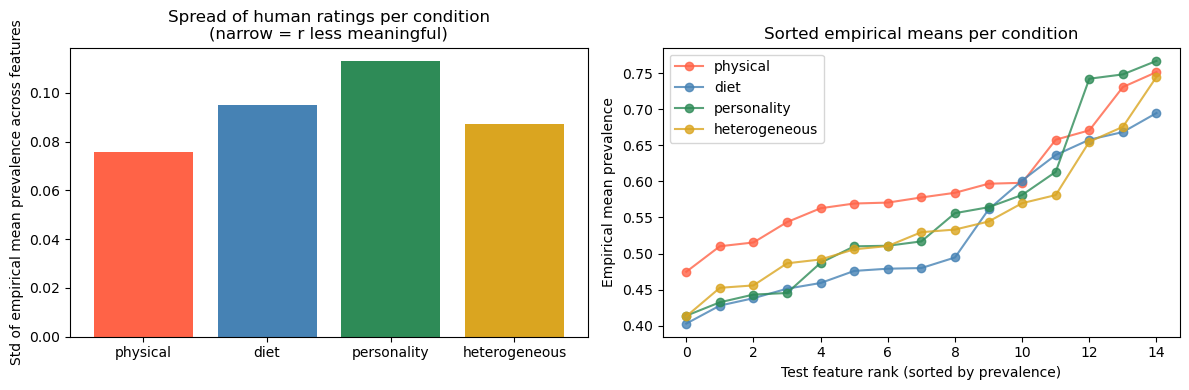

In [17]:
# Empirical mean range per condition — narrow range inflates r regardless of model quality
print(f"{'Condition':<15}  {'std':>6}  {'range':>7}  {'min':>6}  {'max':>6}  per-feature means")
print('-' * 75)
for cond in CONDITIONS:
    # use the empirical_mean from any result for this condition (same across ls)
    em = next(r['empirical_mean'] for r in results if r['condition'] == cond)
    print(f"{cond:<15}  {np.std(em):>6.3f}  {np.ptp(em):>7.3f}  {np.min(em):>6.3f}  {np.max(em):>6.3f}  "
          f"{np.array2string(em.round(2), separator=', ')}")

# Bar chart of std of empirical means per condition
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: std of empirical means
stds = []
for cond in CONDITIONS:
    em = next(r['empirical_mean'] for r in results if r['condition'] == cond)
    stds.append(np.std(em))
axes[0].bar(CONDITIONS, stds, color=[cond_colors[c] for c in CONDITIONS])
axes[0].set_ylabel('Std of empirical mean prevalence across features')
axes[0].set_title('Spread of human ratings per condition\n(narrow = r less meaningful)')

# right: per-condition empirical mean distributions
for cond in CONDITIONS:
    em = next(r['empirical_mean'] for r in results if r['condition'] == cond)
    axes[1].plot(range(J), np.sort(em), 'o-', color=cond_colors[cond], label=cond, alpha=0.8)
axes[1].set_xlabel('Test feature rank (sorted by prevalence)')
axes[1].set_ylabel('Empirical mean prevalence')
axes[1].set_title('Sorted empirical means per condition')
axes[1].legend()

plt.tight_layout()
plt.show()